# Evaluation Metrics Report

This notebook recomputes non-RAG evaluation metrics from saved result JSON files and ground-truth files in `chunk/test` without rerunning generation.

Inputs:
- `act_full.json`
- `output/reasoning_one_call_eval/final_results.json`
- `output/generation_eval/final_past.json`

The metrics include existing report metrics, stricter law-signature metrics, sentencing metrics, defendant alignment, Toi_Danh exact/partial match rates, field completeness, text overlap, and operational token/fallback metrics. RAG retrieval/context metrics are intentionally excluded.

In [1]:
from __future__ import annotations

import ast
import json
import math
import re
import unicodedata
from pathlib import Path
from statistics import mean, median
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from rag.core.sentencing import extract_imprisonment_months

RESULT_FILES = {
    "act": Path("combine_resoning_act_results.json"),
    "one_call": Path("combine_onecal_results.json"),
    "past": Path("combine_past_results.json"),
}

TEST_DIR = Path("chunk/test")
EXPORT_DIR = Path("output/metrics_report")

MANDATORY_SUPPORT_DIEU = {"38", "50", "51", "52", "53", "54", "55", "56", "57", "58", "65", "47"}
EXTRA_SUPPORT_DIEU = {"46", "48"}
SUPPORT_DIEU = MANDATORY_SUPPORT_DIEU | EXTRA_SUPPORT_DIEU

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
plt.style.use("seaborn-v0_8-whitegrid")

## Helper Functions

In [2]:
def load_json(path: Path) -> dict[str, Any]:
    with path.open(encoding="utf-8") as fh:
        return json.load(fh)


def normalize_space(value: Any) -> str:
    return re.sub(r"\s+", " ", str(value or "").strip())


def strip_accents(text: str) -> str:
    norm = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in norm if not unicodedata.combining(ch))


def normalize_text(value: Any) -> str:
    text = strip_accents(normalize_space(value)).lower()
    return re.sub(r"[^a-z0-9]+", " ", text).strip()


def nonempty(value: Any) -> bool:
    if value is None:
        return False
    if isinstance(value, (list, tuple, set, dict)):
        return bool(value)
    text = normalize_space(value)
    return bool(text and text.lower() not in {"none", "null", "[]", "{}"})


def tokenize(value: Any) -> set[str]:
    return {tok for tok in normalize_text(value).split() if tok}


def token_f1(pred: Any, gt: Any) -> float | None:
    pred_tokens = tokenize(pred)
    gt_tokens = tokenize(gt)
    if not pred_tokens and not gt_tokens:
        return None
    if not pred_tokens or not gt_tokens:
        return 0.0
    tp = len(pred_tokens & gt_tokens)
    precision = tp / len(pred_tokens)
    recall = tp / len(gt_tokens)
    return 2 * precision * recall / (precision + recall) if precision + recall else 0.0


TOI_DANH_STOPWORDS = {
    "toi", "ve", "quy", "dinh", "cua", "cac", "bo", "luat", "hinh", "su",
    "theo", "diem", "khoan", "dieu", "va", "hoac", "doi", "voi",
}


def _flatten_toi_danh_values(value: Any) -> list[str]:
    if value is None:
        return []
    if isinstance(value, (list, tuple, set)):
        out: list[str] = []
        for item in value:
            out.extend(_flatten_toi_danh_values(item))
        return out
    text = normalize_space(value)
    if not text:
        return []
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            return _flatten_toi_danh_values(parsed)
        except (SyntaxError, ValueError):
            pass
    return [text]


def normalize_toi_danh(value: Any) -> list[str]:
    normalized: list[str] = []
    for raw in _flatten_toi_danh_values(value):
        text = normalize_text(raw)
        text = re.sub(r"^toi\s+", "", text).strip()
        if text:
            normalized.append(text)
    return sorted(set(normalized))


def toi_danh_partial_match(pred: Any, gt: Any) -> bool:
    pred_items = normalize_toi_danh(pred)
    gt_items = normalize_toi_danh(gt)
    if not pred_items or not gt_items:
        return False
    for pred_item in pred_items:
        pred_tokens = tokenize(pred_item) - TOI_DANH_STOPWORDS
        for gt_item in gt_items:
            gt_tokens = tokenize(gt_item) - TOI_DANH_STOPWORDS
            if pred_item == gt_item or pred_item in gt_item or gt_item in pred_item:
                return True
            if pred_tokens and gt_tokens and pred_tokens & gt_tokens:
                return True
    return False


def normalize_signature(value: Any) -> str:
    sig = normalize_space(value)
    sig = re.sub(r"^(dieu|điều|khoan|khoản|diem|điểm)\s+", "", sig, flags=re.IGNORECASE)
    sig = sig.strip(" .")
    sig = re.sub(r"\s+", "", sig)
    return sig


def signature_set(item: dict[str, Any] | None) -> set[str]:
    if not isinstance(item, dict):
        return set()
    return {sig for raw in item.get("Applied_Law_Clauses") or [] if (sig := normalize_signature(raw))}


def article_set(signatures: set[str]) -> set[str]:
    return {sig.split("-")[0] for sig in signatures if sig}


def khoan_set(signatures: set[str]) -> set[str]:
    out: set[str] = set()
    for sig in signatures:
        parts = [part for part in sig.split("-") if part]
        if not parts:
            continue
        out.add("-".join(parts[:2]) if len(parts) >= 2 else parts[0])
    return out


def set_prf(pred: set[str], gt: set[str]) -> dict[str, float | int]:
    tp = len(pred & gt)
    fp = len(pred - gt)
    fn = len(gt - pred)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1}


def safe_mean(values: list[float | int | None]) -> float | None:
    clean = [float(v) for v in values if v is not None and not pd.isna(v)]
    return mean(clean) if clean else None


def safe_median(values: list[float | int | None]) -> float | None:
    clean = [float(v) for v in values if v is not None and not pd.isna(v)]
    return median(clean) if clean else None


def rate(numerator: float, denominator: float) -> float | None:
    return numerator / denominator if denominator else None


def months_from(item: dict[str, Any] | None, metric_item: dict[str, Any] | None, side: str) -> int:
    if isinstance(metric_item, dict):
        sentence_metrics = metric_item.get("phat_tu_months") or {}
        if side in sentence_metrics:
            return int(sentence_metrics.get(side) or 0)
    if not isinstance(item, dict):
        return 0
    return int(extract_imprisonment_months(item.get("Phat_Tu")))


def load_test_index(test_dir: Path) -> dict[str, dict[str, Any]]:
    index: dict[str, dict[str, Any]] = {}
    for path in sorted(test_dir.rglob("*.json")):
        try:
            data = load_json(path)
        except Exception:
            continue
        index[path.name] = {"path": path, "data": data}
    return index


def flatten_usage(doc: dict[str, Any]) -> dict[str, Any]:
    usage = doc.get("_usage") or {}
    calls = usage.get("calls") if isinstance(usage, dict) else None
    if isinstance(calls, list):
        return {
            "llm_calls": len(calls),
            "input_tokens": sum(int(call.get("prompt_tokens") or 0) for call in calls),
            "output_tokens": sum(int(call.get("completion_tokens") or 0) for call in calls),
            "total_tokens": sum(int(call.get("total_tokens") or 0) for call in calls),
            "used_providers": sorted({str(call.get("provider")) for call in calls if call.get("provider")}),
            "used_models": sorted({str(call.get("model")) for call in calls if call.get("model")}),
            "fallback_errors": sum(len(call.get("fallback_errors") or []) for call in calls),
        }
    if isinstance(usage, dict) and any(key in usage for key in ("prompt_tokens", "completion_tokens", "total_tokens")):
        return {
            "llm_calls": 1,
            "input_tokens": int(usage.get("prompt_tokens") or 0),
            "output_tokens": int(usage.get("completion_tokens") or 0),
            "total_tokens": int(usage.get("total_tokens") or 0),
            "used_providers": [str(usage.get("provider"))] if usage.get("provider") else [],
            "used_models": [str(usage.get("model"))] if usage.get("model") else [],
            "fallback_errors": len(usage.get("fallback_errors") or []),
        }
    return {"llm_calls": 0, "input_tokens": 0, "output_tokens": 0, "total_tokens": 0, "used_providers": [], "used_models": [], "fallback_errors": 0}


def fallback_used(doc: dict[str, Any], report: dict[str, Any]) -> bool:
    config = report.get("config") or {}
    requested_provider = str(config.get("provider") or "")
    requested_model = str(config.get("model") or "")
    llm = doc.get("llm") or {}
    if llm:
        return bool(
            str(llm.get("used_provider") or "") != str(llm.get("requested_provider") or "")
            or str(llm.get("used_model") or "") != str(llm.get("requested_model") or "")
        )
    usage_info = flatten_usage(doc)
    used_providers = set(usage_info["used_providers"])
    used_models = set(usage_info["used_models"])
    provider_changed = bool(used_providers and requested_provider and used_providers != {requested_provider})
    model_changed = bool(used_models and requested_model and used_models != {requested_model})
    return provider_changed or model_changed

## Load Reports And Build Rows

In [3]:
reports: dict[str, dict[str, Any]] = {}
missing_paths = []
for model_name, path in RESULT_FILES.items():
    if path.exists():
        reports[model_name] = load_json(path)
    else:
        missing_paths.append(path)

if missing_paths:
    print("Missing result files:")
    for path in missing_paths:
        print(f"- {path}")

test_index = load_test_index(TEST_DIR)
print(f"Loaded {len(reports)} reports and {len(test_index)} ground-truth test files.")
display(pd.DataFrame([
    {
        "model": model,
        "path": str(RESULT_FILES[model]),
        "n_per_doc": len(report.get("per_doc") or []),
        "test_dir": (report.get("config") or {}).get("test_dir"),
        "input_fields": ",".join((report.get("config") or {}).get("input_fields") or []),
        "query_fields": ",".join((report.get("config") or {}).get("query_fields") or []),
    }
    for model, report in reports.items()
]))

Loaded 3 reports and 361 ground-truth test files.


,model,path,n_per_doc,test_dir,input_fields,query_fields
0,act,combine_resoning_act_results.json,361,chunk/test,"THONG_TIN_CHUNG.Thong_Tin_Bi_Cao,Synthetic_sum...","Synthetic_summary,THONG_TIN_CHUNG.Thong_Tin_Bi..."
1,one_call,combine_onecal_results.json,361,chunk/test/2023,"THONG_TIN_CHUNG.Thong_Tin_Bi_Cao,Synthetic_sum...",
2,past,combine_past_results.json,361,chunk/test/2023,"THONG_TIN_CHUNG.Thong_Tin_Bi_Cao,Synthetic_sum...","Synthetic_summary_2,THONG_TIN_CHUNG.Thong_Tin_..."


In [4]:
doc_rows: list[dict[str, Any]] = []
def_rows: list[dict[str, Any]] = []

for model_name, report in reports.items():
    for doc in report.get("per_doc") or []:
        usage_info = flatten_usage(doc)
        source_file = doc.get("source_file") or ""
        alignment = doc.get("defendant_alignment") or {}
        defendants = doc.get("defendants") or []
        status = doc.get("status") or ""
        reason = doc.get("reason") or ""
        gt_count = int(alignment.get("matched_count") or 0) + int(alignment.get("gt_only_count") or 0)
        pred_count = int(alignment.get("matched_count") or 0) + int(alignment.get("pred_only_count") or 0)
        if not alignment:
            gt_count = sum(1 for item in defendants if item.get("ground_truth"))
            pred_count = sum(1 for item in defendants if item.get("prediction"))
        doc_rows.append({
            "model": model_name,
            "doc_id": doc.get("doc_id"),
            "source_file": source_file,
            "status": status,
            "reason": reason,
            "gt_file_exists": source_file in test_index,
            "matched_count": int(alignment.get("matched_count") or 0),
            "gt_only_count": int(alignment.get("gt_only_count") or 0),
            "pred_only_count": int(alignment.get("pred_only_count") or 0),
            "gt_defendant_count": gt_count,
            "pred_defendant_count": pred_count,
            "llm_calls": usage_info["llm_calls"],
            "input_tokens": usage_info["input_tokens"],
            "output_tokens": usage_info["output_tokens"],
            "total_tokens": usage_info["total_tokens"],
            "fallback_errors": usage_info["fallback_errors"],
            "fallback_used": fallback_used(doc, report),
        })

        for idx, defendant in enumerate(defendants):
            gt = defendant.get("ground_truth") or {}
            pred = defendant.get("prediction") or {}
            metrics = defendant.get("metrics") or {}
            gt_full = signature_set(gt)
            pred_full = signature_set(pred)
            gt_article = article_set(gt_full)
            pred_article = article_set(pred_full)
            gt_khoan = khoan_set(gt_full)
            pred_khoan = khoan_set(pred_full)
            article_prf = set_prf(pred_article, gt_article)
            khoan_prf = set_prf(pred_khoan, gt_khoan)
            full_prf = set_prf(pred_full, gt_full)
            gt_mandatory = gt_article & MANDATORY_SUPPORT_DIEU
            pred_mandatory = pred_article & MANDATORY_SUPPORT_DIEU
            mandatory_recall = None if not gt_mandatory else len(gt_mandatory & pred_mandatory) / len(gt_mandatory)
            gt_offense = gt_article - SUPPORT_DIEU
            pred_offense = pred_article - SUPPORT_DIEU
            offense_prf = set_prf(pred_offense, gt_offense)
            gt_months = months_from(gt, metrics, "ground_truth")
            pred_months = months_from(pred, metrics, "prediction")
            sentence_error = pred_months - gt_months
            def_rows.append({
                "model": model_name,
                "doc_id": doc.get("doc_id"),
                "source_file": source_file,
                "defendant_index": idx,
                "status": status,
                "Bi_Cao": defendant.get("Bi_Cao") or (gt.get("Bi_Cao") or pred.get("Bi_Cao")),
                "has_ground_truth": bool(gt),
                "has_prediction": bool(pred),
                "gt_full": sorted(gt_full),
                "pred_full": sorted(pred_full),
                "gt_article": sorted(gt_article),
                "pred_article": sorted(pred_article),
                "article_precision": article_prf["precision"],
                "article_recall": article_prf["recall"],
                "article_f1": article_prf["f1"],
                "article_exact_match": gt_article == pred_article,
                "article_tp": article_prf["tp"],
                "article_fp": article_prf["fp"],
                "article_fn": article_prf["fn"],
                "khoan_precision": khoan_prf["precision"],
                "khoan_recall": khoan_prf["recall"],
                "khoan_f1": khoan_prf["f1"],
                "full_signature_precision": full_prf["precision"],
                "full_signature_recall": full_prf["recall"],
                "full_signature_f1": full_prf["f1"],
                "mandatory_support_article_recall": mandatory_recall,
                "offense_article_precision": offense_prf["precision"],
                "offense_article_recall": offense_prf["recall"],
                "offense_article_f1": offense_prf["f1"],
                "gt_months": gt_months,
                "pred_months": pred_months,
                "sentence_error_months": sentence_error,
                "sentence_abs_error_months": abs(sentence_error),
                "sentence_exact_match": gt_months == pred_months,
                "sentence_within_3_months": abs(sentence_error) <= 3,
                "sentence_within_6_months": abs(sentence_error) <= 6,
                "sentence_within_12_months": abs(sentence_error) <= 12,
                "custodial_class_match": (gt_months > 0) == (pred_months > 0),
                "zero_month_error": (gt_months == 0) != (pred_months == 0),
                "gt_Toi_Danh": gt.get("Toi_Danh", ""),
                "pred_Toi_Danh": pred.get("Toi_Danh", ""),
                "toi_danh_present": nonempty(pred.get("Toi_Danh")),
                "gt_toi_danh_normalized": normalize_toi_danh(gt.get("Toi_Danh")),
                "pred_toi_danh_normalized": normalize_toi_danh(pred.get("Toi_Danh")),
                "toi_danh_exact_match": normalize_toi_danh(gt.get("Toi_Danh")) == normalize_toi_danh(pred.get("Toi_Danh")),
                "toi_danh_partial_match": toi_danh_partial_match(pred.get("Toi_Danh"), gt.get("Toi_Danh")),
                "toi_danh_exact_normalized_match": normalize_text(gt.get("Toi_Danh")) == normalize_text(pred.get("Toi_Danh")),
                "toi_danh_token_f1": token_f1(pred.get("Toi_Danh"), gt.get("Toi_Danh")),
                "phat_tu_present": nonempty(pred.get("Phat_Tu")),
                "phat_tien_present": nonempty(pred.get("Phat_Tien")),
                "gt_phat_tien_present": nonempty(gt.get("Phat_Tien")),
                "phat_tien_exact_normalized_match": normalize_text(gt.get("Phat_Tien")) == normalize_text(pred.get("Phat_Tien")),
                "trach_nhiem_dan_su_present": nonempty(pred.get("Trach_Nhiem_Dan_Su")),
                "gt_trach_nhiem_dan_su_present": nonempty(gt.get("Trach_Nhiem_Dan_Su")),
                "trach_nhiem_dan_su_token_f1": token_f1(pred.get("Trach_Nhiem_Dan_Su"), gt.get("Trach_Nhiem_Dan_Su")),
                "xu_ly_vat_chung_present": nonempty(pred.get("Xu_Ly_Vat_Chung")),
                "gt_xu_ly_vat_chung_present": nonempty(gt.get("Xu_Ly_Vat_Chung")),
                "xu_ly_vat_chung_token_f1": token_f1(pred.get("Xu_Ly_Vat_Chung"), gt.get("Xu_Ly_Vat_Chung")),
                "applied_law_nonempty": bool(pred_full),
            })

doc_df = pd.DataFrame(doc_rows)
def_df = pd.DataFrame(def_rows)

display(doc_df.head())
display(def_df.head())

,model,doc_id,source_file,status,reason,gt_file_exists,matched_count,gt_only_count,pred_only_count,gt_defendant_count,pred_defendant_count,llm_calls,input_tokens,output_tokens,total_tokens,fallback_errors,fallback_used
0,act,01-02-2024-Khanh_Hoa-2ta1430918t1cvn,01-02-2024-Khanh_Hoa-2ta1430918t1cvn.json,processed,ok,True,1,0,0,1,1,3,23072,4722,27794,0,False
1,act,01-04-2025-Tuyen_Quang-2ta1791873t1cvn,01-04-2025-Tuyen_Quang-2ta1791873t1cvn.json,processed,ok,True,2,0,0,2,2,3,29283,6655,35938,0,False
2,act,01-08-2024-Bac_Giang-2ta1610530t1cvn,01-08-2024-Bac_Giang-2ta1610530t1cvn.json,processed,ok,True,1,0,0,1,1,3,23581,4934,28515,0,False
3,act,01-08-2025-Hai_Phong-2ta1913320t1cvn,01-08-2025-Hai_Phong-2ta1913320t1cvn.json,processed,ok,True,1,0,0,1,1,3,26546,4820,31366,0,False
4,act,02-04-2025-Ha_Noi-2ta1950007t1cvn,02-04-2025-Ha_Noi-2ta1950007t1cvn.json,processed,ok,True,1,0,0,1,1,3,24463,5193,29656,0,False


,model,doc_id,source_file,defendant_index,status,Bi_Cao,has_ground_truth,has_prediction,gt_full,pred_full,gt_article,pred_article,article_precision,article_recall,article_f1,article_exact_match,article_tp,article_fp,article_fn,khoan_precision,khoan_recall,khoan_f1,full_signature_precision,full_signature_recall,full_signature_f1,mandatory_support_article_recall,offense_article_precision,offense_article_recall,offense_article_f1,gt_months,pred_months,sentence_error_months,sentence_abs_error_months,sentence_exact_match,sentence_within_3_months,sentence_within_6_months,sentence_within_12_months,custodial_class_match,zero_month_error,gt_Toi_Danh,pred_Toi_Danh,toi_danh_present,gt_toi_danh_normalized,pred_toi_danh_normalized,toi_danh_exact_match,toi_danh_partial_match,toi_danh_exact_normalized_match,toi_danh_token_f1,phat_tu_present,phat_tien_present,gt_phat_tien_present,phat_tien_exact_normalized_match,trach_nhiem_dan_su_present,gt_trach_nhiem_dan_su_present,trach_nhiem_dan_su_token_f1,xu_ly_vat_chung_present,gt_xu_ly_vat_chung_present,xu_ly_vat_chung_token_f1,applied_law_nonempty
0,act,01-02-2024-Khanh_Hoa-2ta1430918t1cvn,01-02-2024-Khanh_Hoa-2ta1430918t1cvn.json,0,processed,NTM,True,True,"[173-1, 51-1-s, 51-2]","[173-1, 51-1-b, 51-1-s]","[173, 51]","[173, 51]",1.000000,1.000000,1.000000,True,2,0,0,1.000000,0.666667,0.800000,0.666667,0.666667,0.666667,1.000000,1.0,1.000000,1.0,12,0,-12,12,False,False,False,True,False,True,['Trộm cắp tài sản'],Tội trộm cắp tài sản,True,[trom cap tai san],[trom cap tai san],True,True,False,0.888889,True,False,False,True,True,True,0.320000,True,False,0.0,True
1,act,01-04-2025-Tuyen_Quang-2ta1791873t1cvn,01-04-2025-Tuyen_Quang-2ta1791873t1cvn.json,0,processed,Nguyễn Hải C,True,True,"[353-2-d, 353-5, 356-2-b, 356-2-c, 38, 41, 51-...","[353-2-d, 51-1-b, 51-1-s, 51-1-v, 51-1-x, 52-1-c]","[353, 356, 38, 41, 51, 54, 55]","[353, 51, 52]",0.666667,0.285714,0.400000,False,2,1,5,0.666667,0.222222,0.333333,0.666667,0.333333,0.444444,0.250000,1.0,0.333333,0.5,60,84,24,24,False,False,False,False,True,False,"['Lợi dụng chức vụ, quyền hạn trong khi thi hà...",Tội tham ô tài sản,True,[loi dung chuc vu quyen han trong khi thi hanh...,[tham o tai san],False,True,False,0.400000,True,False,False,True,True,True,0.216216,True,False,0.0,True
2,act,01-04-2025-Tuyen_Quang-2ta1791873t1cvn,01-04-2025-Tuyen_Quang-2ta1791873t1cvn.json,1,processed,Triệu Thị T1,True,True,"[353-3-a, 38, 51-1-b, 51-1-s, 51-2, 54-1]","[353-3-a, 51-1-b, 51-1-s, 51-1-v, 51-1-x, 52-1-c]","[353, 38, 51, 54]","[353, 51, 52]",0.666667,0.500000,0.571429,False,2,1,2,0.666667,0.400000,0.500000,0.500000,0.500000,0.500000,0.333333,1.0,1.000000,1.0,144,180,36,36,False,False,False,False,True,False,['Tham ô tài sản'],Tội tham ô tài sản,True,[tham o tai san],[tham o tai san],True,True,False,0.888889,True,False,False,True,True,True,0.250000,True,False,0.0,True
3,act,01-08-2024-Bac_Giang-2ta1610530t1cvn,01-08-2024-Bac_Giang-2ta1610530t1cvn.json,0,processed,Nguyễn Văn H,True,True,"[227-1-đ, 227-3, 51-1-i, 51-1-s, 51-2, 65]","[227-1-đ, 51-1-i, 51-1-s, 51-1-x]","[227, 51, 65]","[227, 51]",1.000000,0.666667,0.800000,False,2,0,1,1.000000,0.400000,0.571429,0.750000,0.500000,0.600000,0.500000,1.0,1.000000,1.0,6,0,-6,6,False,False,True,True,False,True,['Vi phạm quy định về khai thác tài nguyên'],"Tội vi phạm quy định về nghiên cứu, thăm dò, k...",True,[vi pham quy inh ve khai thac tai nguyen],[vi pham quy inh ve nghien cuu tham do khai th...,False,True,False,0.782609,True,False,True,False,False,False,NaN,True,False,0.0,True
4,act,01-08-2025-Hai_Phong-2ta1913320t1cvn,01-08-2025-Hai_Phong-2ta1913320t1cvn.json,0,processed,Phạm Thị L,True,True,"[174-4-a, 38, 48, 51-1-b, 51-1-s, 52-1-g]","[174-4-a, 51-1-b, 51-1-s, 52-1-g]","[174, 38, 48, 51, 52]","[174, 51, 52]",1.000000,0.600000,0.750000,False,3,0,2,1.000000,0.600000,0.750000,1.000000,0.666667,0.800000,0.666667,1.0,1.000000,1.0,156,144,-12,12,False,False,False,True,True,False,['lừa đảo chiếm đảo chiếm đoạt tài sản'],Tội lừa đảo c

## Aggregate Metrics

In [5]:
def aggregate_metrics(model_name: str, report: dict[str, Any]) -> dict[str, Any]:
    summary = report.get("summary") or {}
    summary_metrics = summary.get("metrics") or {}
    docs = doc_df[doc_df["model"] == model_name].copy()
    defs = def_df[(def_df["model"] == model_name) & (def_df["status"] == "processed")].copy()
    n_total = int(summary.get("n_total") or len(docs))
    n_processed = int(summary.get("n_processed") or (docs["status"] == "processed").sum())
    n_failed = int(summary.get("n_failed") or (docs["status"] == "failed").sum())
    n_skipped = int(summary.get("n_skipped") or (docs["status"] == "skipped").sum())
    gt_total = docs["gt_defendant_count"].sum()
    pred_total = docs["pred_defendant_count"].sum()
    article_pred_total = defs["article_tp"].sum() + defs["article_fp"].sum()
    article_gt_total = defs["article_tp"].sum() + defs["article_fn"].sum()
    return {
        "model": model_name,
        "n_total": n_total,
        "n_processed": n_processed,
        "n_failed": n_failed,
        "n_skipped": n_skipped,
        "processed_rate": rate(n_processed, n_total),
        "failure_rate": rate(n_failed, n_total),
        "skip_rate": rate(n_skipped, n_total),
        "resume_completeness": rate(docs["source_file"].nunique(), len(test_index)),
        "existing_law_article_precision_macro": summary_metrics.get("law_clause_set_precision_macro"),
        "existing_law_article_recall_macro": summary_metrics.get("law_clause_set_recall_macro"),
        "existing_law_article_f1_macro": summary_metrics.get("law_clause_set_f1_macro"),
        "existing_sentence_rmse_months_macro": summary_metrics.get("phat_tu_rmse_months_macro"),
        "per_defendant_article_f1_macro": safe_mean(defs["article_f1"].tolist()),
        "exact_article_set_match_rate": safe_mean(defs["article_exact_match"].astype(float).tolist()),
        "sentence_exact_match_rate": safe_mean(defs["sentence_exact_match"].astype(float).tolist()),
        "sentence_rmse_months_micro": (math.sqrt(m) if (m := safe_mean((defs["sentence_error_months"] ** 2).tolist())) is not None else None),
        "sentence_mae_months_micro": safe_mean(defs["sentence_abs_error_months"].tolist()),
        "sentence_mae_months_macro": safe_mean(defs.groupby("doc_id")["sentence_abs_error_months"].mean().tolist()),
        "sentence_median_ae_months": safe_median(defs["sentence_abs_error_months"].tolist()),
        "sentence_within_3_month_rate": safe_mean(defs["sentence_within_3_months"].astype(float).tolist()),
        "sentence_within_6_month_rate": safe_mean(defs["sentence_within_6_months"].astype(float).tolist()),
        "sentence_within_12_month_rate": safe_mean(defs["sentence_within_12_months"].astype(float).tolist()),
        "sentence_bias_months": safe_mean(defs["sentence_error_months"].tolist()),
        "custodial_class_accuracy": safe_mean(defs["custodial_class_match"].astype(float).tolist()),
        "zero_month_error_rate": safe_mean(defs["zero_month_error"].astype(float).tolist()),
        "defendant_name_match_rate": rate(docs["matched_count"].sum(), gt_total),
        "missing_defendant_rate": rate(docs["gt_only_count"].sum(), gt_total),
        "extra_defendant_rate": rate(docs["pred_only_count"].sum(), pred_total),
        "full_signature_precision_macro": safe_mean(defs["full_signature_precision"].tolist()),
        "full_signature_recall_macro": safe_mean(defs["full_signature_recall"].tolist()),
        "full_signature_f1_macro": safe_mean(defs["full_signature_f1"].tolist()),
        "khoan_level_precision_macro": safe_mean(defs["khoan_precision"].tolist()),
        "khoan_level_recall_macro": safe_mean(defs["khoan_recall"].tolist()),
        "khoan_level_f1_macro": safe_mean(defs["khoan_f1"].tolist()),
        "mandatory_support_article_recall": safe_mean(defs["mandatory_support_article_recall"].tolist()),
        "offense_article_precision_macro": safe_mean(defs["offense_article_precision"].tolist()),
        "offense_article_recall_macro": safe_mean(defs["offense_article_recall"].tolist()),
        "offense_article_f1_macro": safe_mean(defs["offense_article_f1"].tolist()),
        "overcitation_rate": rate(defs["article_fp"].sum(), article_pred_total),
        "undercitation_rate": rate(defs["article_fn"].sum(), article_gt_total),
        "toi_danh_present_rate": safe_mean(defs["toi_danh_present"].astype(float).tolist()),
        "toi_danh_exact_match_rate": safe_mean(defs["toi_danh_exact_match"].astype(float).tolist()),
        "toi_danh_partial_match_rate": safe_mean(defs["toi_danh_partial_match"].astype(float).tolist()),
        "phat_tu_present_rate": safe_mean(defs["phat_tu_present"].astype(float).tolist()),
        "phat_tien_present_when_gt_rate": safe_mean(defs.loc[defs["gt_phat_tien_present"], "phat_tien_present"].astype(float).tolist()),
        "trach_nhiem_dan_su_present_when_gt_rate": safe_mean(defs.loc[defs["gt_trach_nhiem_dan_su_present"], "trach_nhiem_dan_su_present"].astype(float).tolist()),
        "xu_ly_vat_chung_present_when_gt_rate": safe_mean(defs.loc[defs["gt_xu_ly_vat_chung_present"], "xu_ly_vat_chung_present"].astype(float).tolist()),
        "applied_law_nonempty_rate": safe_mean(defs["applied_law_nonempty"].astype(float).tolist()),
        "toi_danh_exact_normalized_match_rate": safe_mean(defs["toi_danh_exact_normalized_match"].astype(float).tolist()),
        "toi_danh_token_f1": safe_mean(defs["toi_danh_token_f1"].tolist()),
        "phat_tien_exact_normalized_match_rate": safe_mean(defs["phat_tien_exact_normalized_match"].astype(float).tolist()),
        "trach_nhiem_dan_su_token_f1": safe_mean(defs["trach_nhiem_dan_su_token_f1"].tolist()),
        "xu_ly_vat_chung_token_f1": safe_mean(defs["xu_ly_vat_chung_token_f1"].tolist()),
        "avg_input_tokens": safe_mean(docs["input_tokens"].tolist()),
        "avg_output_tokens": safe_mean(docs["output_tokens"].tolist()),
        "avg_total_tokens": safe_mean(docs["total_tokens"].tolist()),
        "total_input_tokens": docs["input_tokens"].sum(),
        "total_output_tokens": docs["output_tokens"].sum(),
        "total_tokens": docs["total_tokens"].sum(),
        "avg_llm_calls_per_doc": safe_mean(docs["llm_calls"].tolist()),
        "fallback_rate": safe_mean(docs["fallback_used"].astype(float).tolist()),
        "parse_failure_rate": safe_mean((docs["reason"] == "parse_error").astype(float).tolist()),
        "generation_failure_rate": safe_mean((docs["reason"] == "generation_error").astype(float).tolist()),
    }


metrics_df = pd.DataFrame([aggregate_metrics(model, report) for model, report in reports.items()]).set_index("model")
display(metrics_df.round(4))

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(EXPORT_DIR / "summary_metrics.csv")
doc_df.to_csv(EXPORT_DIR / "doc_rows.csv", index=False)
def_df.to_csv(EXPORT_DIR / "defendant_rows.csv", index=False)
print(f"Exported CSVs to {EXPORT_DIR}")

,n_total,n_processed,n_failed,n_skipped,processed_rate,failure_rate,skip_rate,resume_completeness,existing_law_article_precision_macro,existing_law_article_recall_macro,existing_law_article_f1_macro,existing_sentence_rmse_months_macro,per_defendant_article_f1_macro,exact_article_set_match_rate,sentence_exact_match_rate,sentence_mae_months,sentence_median_ae_months,sentence_within_3_month_rate,sentence_within_6_month_rate,sentence_within_12_month_rate,sentence_bias_months,custodial_class_accuracy,zero_month_error_rate,defendant_name_match_rate,missing_defendant_rate,extra_defendant_rate,full_signature_precision_macro,full_signature_recall_macro,full_signature_f1_macro,khoan_level_precision_macro,khoan_level_recall_macro,khoan_level_f1_macro,mandatory_support_article_recall,offense_article_precision_macro,offense_article_recall_macro,offense_article_f1_macro,overcitation_rate,undercitation_rate,toi_danh_present_rate,toi_danh_exact_match_rate,toi_danh_partial_match_rate,phat_tu_present_rate,phat_tien_present_when_gt_rate,trach_nhiem_dan_su_present_when_gt_rate,xu_ly_vat_chung_present_when_gt_rate,applied_law_nonempty_rate,toi_danh_exact_normalized_match_rate,toi_danh_token_f1,phat_tien_exact_normalized_match_rate,trach_nhiem_dan_su_token_f1,xu_ly_vat_chung_token_f1,avg_input_tokens,avg_output_tokens,avg_total_tokens,total_input_tokens,total_output_tokens,total_tokens,avg_llm_calls_per_doc,fallback_rate,parse_failure_rate,generation_failure_rate
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
act,361,361,0,0,1.0,0.0,0.0,1.0,0.7915,0.5510,0.6298,35.4816,0.6197,0.1020,0.2525,34.4799,21.0,0.2609,0.3110,0.4415,-10.4666,0.8746,0.1254,0.9983,0.0017,0.0034,0.6273,0.4239,0.4893,0.7396,0.4294,0.5244,0.5281,0.7603,0.6095,0.6561,0.1909,0.5244,0.9933,0.6221,0.8645,0.9916,0.0519,0.7770,None,0.9933,0.0870,0.7251,0.8395,0.2663,0.0,27447.5152,5208.2410,33862.3518,9908553,1880175,12224309,3.0388,0.3213,0.0,0.0
one_call,361,361,0,0,1.0,0.0,0.0,1.0,0.8239,0.4899,0.5940,59.9104,0.5896,0.0889,0.0889,57.0000,36.0,0.1158,0.1795,0.2869,-35.3289,0.8087,0.1913,0.9983,0.0017,0.0000,0.4248,0.2225,0.2821,0.6779,0.3329,0.4306,0.4699,0.7173,0.5794,0.6201,0.1660,0.5762,0.9966,0.6527,0.8758,0.9966,0.1429,0.7662,None,0.9966,0.6158,0.7893,0.8641,0.2411,0.0,1973.3102,834.5928,2837.1247,712365,301288,1024202,1.0000,0.0222,0.0,0.0
past,361,361,0,0,1.0,0.0,0.0,1.0,0.6646,0.5641,0.5924,53.9669,0.3861,0.0889,0.1974,73.6301,36.0,0.2052,0.2418,0.3464,-3.6614,0.5582,0.4418,0.7215,0.2785,0.2821,0.3437,0.2739,0.2954,0.3903,0.2768,0.3119,0.4470,0.4460,0.4085,0.4150,0.3776,0.5662,0.7830,0.3974,0.5203,0.7830,0.1429,0.7698,None,0.7608,0.3908,0.4819,0.8497,0.2101,0.0,27917.2521,1150.6537,29456.7147,10078128,415386,10633874,1.0000,0.1967,0.0,0.0


Exported CSVs to output/metrics_report


## Quick Metric Views

In [6]:
headline_cols = [
    "processed_rate",
    "existing_law_article_f1_macro",
    "full_signature_f1_macro",
    "offense_article_f1_macro",
    "mandatory_support_article_recall",
    "exact_article_set_match_rate",
    "toi_danh_exact_match_rate",
    "toi_danh_partial_match_rate",
    "sentence_mae_months",
    "existing_sentence_rmse_months_macro",
    "sentence_within_6_month_rate",
    "defendant_name_match_rate",
    "missing_defendant_rate",
    "avg_input_tokens",
    "avg_output_tokens",
    "avg_total_tokens",
    "fallback_rate",
]

headline_df = metrics_df[headline_cols].copy()
display(headline_df.round(4).T)

model,act,one_call,past
processed_rate,1.0000,1.0000,1.0000
existing_law_article_f1_macro,0.6298,0.5940,0.5924
full_signature_f1_macro,0.4893,0.2821,0.2954
offense_article_f1_macro,0.6561,0.6201,0.4150
mandatory_support_article_recall,0.5281,0.4699,0.4470
exact_article_set_match_rate,0.1020,0.0889,0.0889
toi_danh_exact_match_rate,0.6221,0.6527,0.3974
toi_danh_partial_match_rate,0.8645,0.8758,0.5203
sentence_mae_months,34.4799,57.0000,73.6301
existing_sentence_rmse_months_macro,35.4816,59.9104,53.9669


## Basic Plots

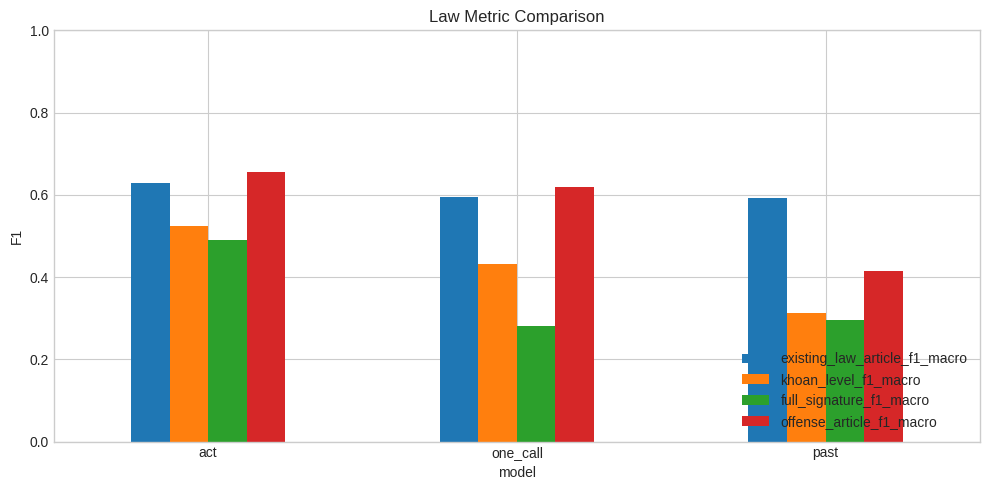

In [7]:
law_plot_cols = [
    "existing_law_article_f1_macro",
    "khoan_level_f1_macro",
    "full_signature_f1_macro",
    "offense_article_f1_macro",
]

ax = metrics_df[law_plot_cols].plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Law Metric Comparison")
ax.set_ylabel("F1")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

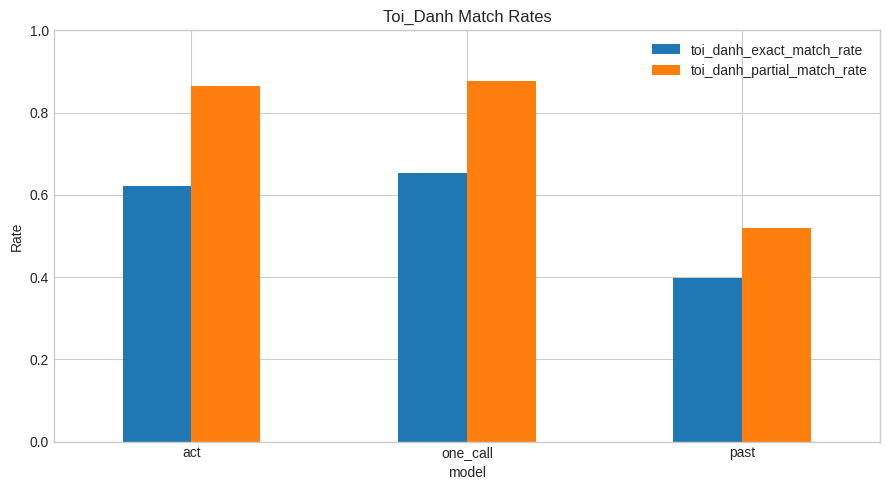

In [8]:
toi_danh_plot_cols = ["toi_danh_exact_match_rate", "toi_danh_partial_match_rate"]
ax = metrics_df[toi_danh_plot_cols].plot(kind="bar", figsize=(9, 5), rot=0)
ax.set_title("Toi_Danh Match Rates")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

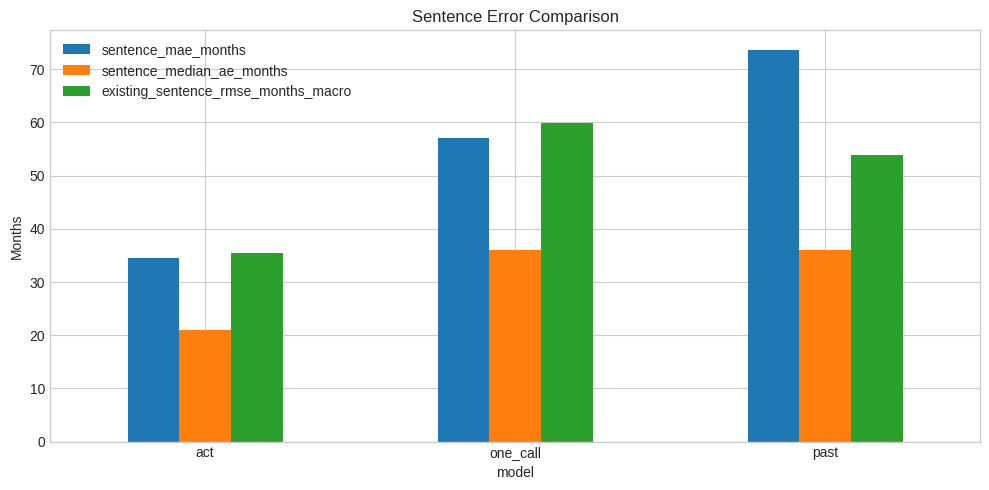

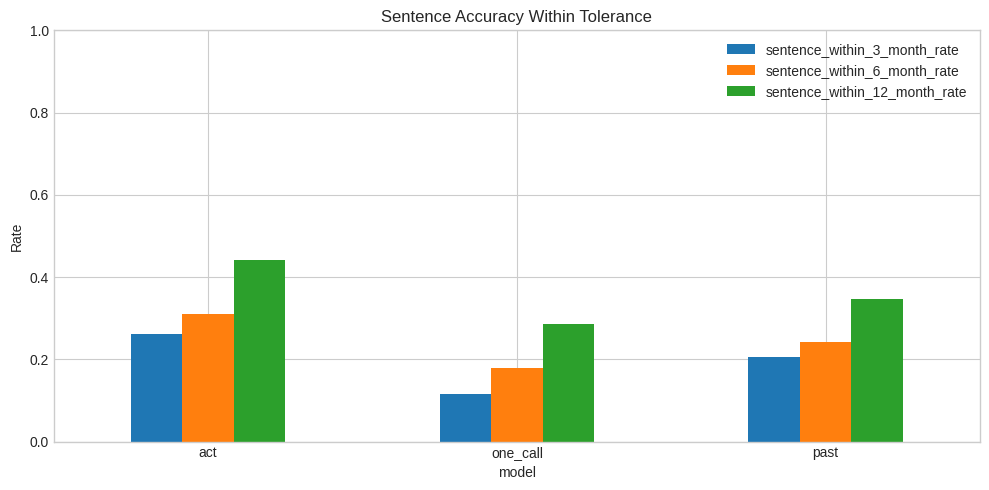

In [9]:
sentence_plot_cols = [
    "sentence_mae_months",
    "sentence_median_ae_months",
    "existing_sentence_rmse_months_macro",
]

ax = metrics_df[sentence_plot_cols].plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Sentence Error Comparison")
ax.set_ylabel("Months")
plt.tight_layout()
plt.show()

ax = metrics_df[["sentence_within_3_month_rate", "sentence_within_6_month_rate", "sentence_within_12_month_rate"]].plot(
    kind="bar", figsize=(10, 5), rot=0
)
ax.set_title("Sentence Accuracy Within Tolerance")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

/tmp/ipykernel_16374/1850733060.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=models, showfliers=False)


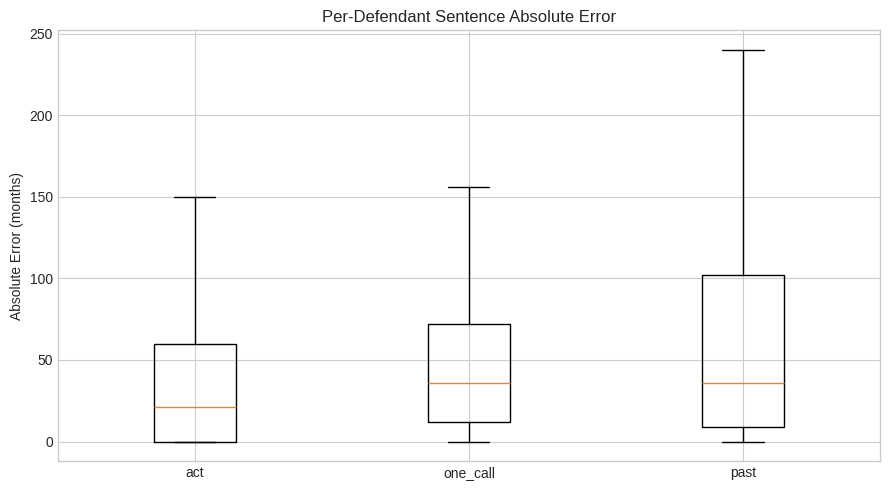

In [10]:
plot_df = def_df[def_df["status"] == "processed"].copy()
models = list(reports.keys())
box_data = [plot_df.loc[plot_df["model"] == model, "sentence_abs_error_months"].dropna() for model in models]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(box_data, labels=models, showfliers=False)
ax.set_title("Per-Defendant Sentence Absolute Error")
ax.set_ylabel("Absolute Error (months)")
plt.tight_layout()
plt.show()

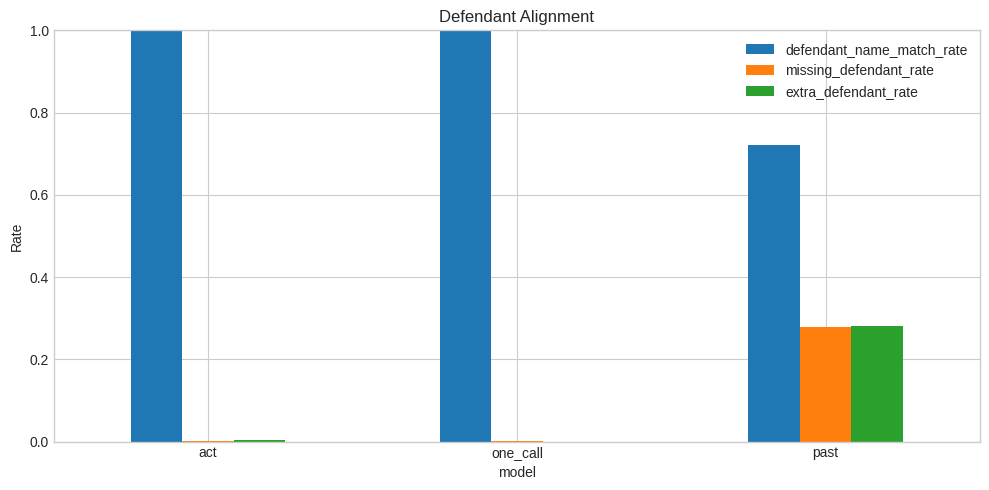

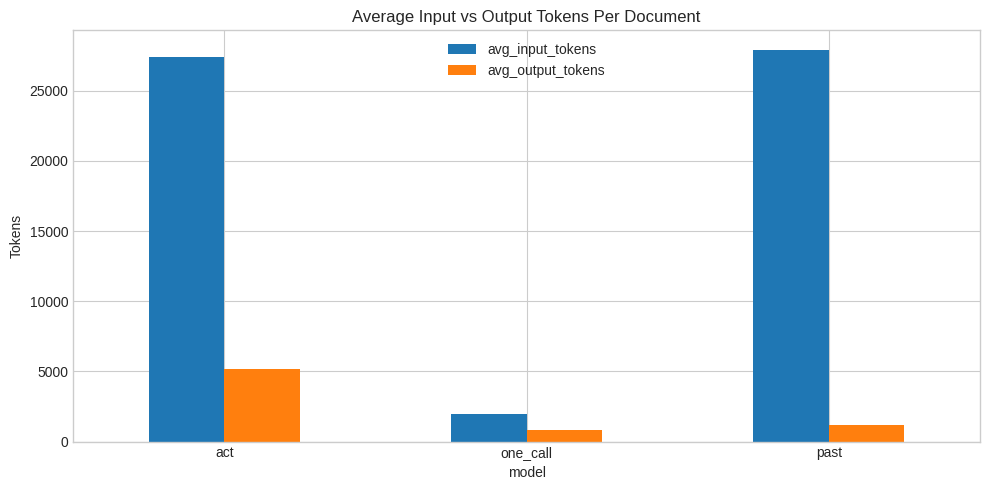

In [11]:
alignment_cols = ["defendant_name_match_rate", "missing_defendant_rate", "extra_defendant_rate"]
ax = metrics_df[alignment_cols].plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Defendant Alignment")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

token_cols = ["avg_input_tokens", "avg_output_tokens"]
ax = metrics_df[token_cols].plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Average Input vs Output Tokens Per Document")
ax.set_ylabel("Tokens")
plt.tight_layout()
plt.show()

## Drill-Down Tables

In [12]:
# Worst sentence errors by model.
display(
    def_df.sort_values("sentence_abs_error_months", ascending=False)[
        [
            "model",
            "source_file",
            "Bi_Cao",
            "gt_months",
            "pred_months",
            "sentence_abs_error_months",
            "gt_full",
            "pred_full",
        ]
    ].head(30)
)

# Lowest strict legal signature F1 by model.
display(
    def_df.sort_values("full_signature_f1", ascending=True)[
        ["model", "source_file", "Bi_Cao", "full_signature_f1", "gt_full", "pred_full"]
    ].head(30)
)

,model,source_file,Bi_Cao,gt_months,pred_months,sentence_abs_error_months,gt_full,pred_full
1942,past,30-10-2024-Hai_Phong-2ta1833114t1cvn.json,Đinh Thị T,360,0,360,"[194-4-h, 39, 51-1-s, 51-2]",[]
1943,past,30-10-2024-Hai_Phong-2ta1833114t1cvn.json,Lò Văn T,0,360,360,[],"[251-4-b, 51-1-s, 51-1-t]"
987,one_call,19-11-2025-Ho_Chi_Minh-2ta2079272t1cvn.json,Nguyễn Nguyên T,360,0,360,"[17, 251-4-b, 39, 51-1-s, 51-2, 52-1-g, 58]","[251-4, 51-1-s]"
867,one_call,10-01-2025-Khanh_Hoa-2ta1738112t1cvn.json,Đặng Thị Mỹ H,360,0,360,"[251-4-h, 39, 47, 51-1-s, 52-1-g]","[251-4, 51-1-a, 51-1-b, 51-2, 52-2]"
1067,one_call,25-02-2025-Dien_Bien-2ta1748471t1cvn.json,Chảo Cáo M,360,0,360,"[17, 251-4-h, 39, 51-1-r, 51-1-s, 52-1-h, 58]","[251-4, 51-1-q, 52-2-a]"
1036,one_call,23-07-2025-Dien_Bien-2ta1880919t1cvn.json,Ly Súa B,360,0,360,"[17, 251-4-h, 39, 51-1-s, 58]","[251-4, 51-1-s]"
1920,past,30-07-2024-Hoa_Binh-2ta1610407t1cvn.json,Dương Quang X,360,0,360,"[251-4-e, 39, 51-1-s, 51-1-t, 51-2]",[]
793,one_call,04-06-2025-Khanh_Hoa-2ta1896878t1cvn.json,Nguyễn Thanh H,360,0,360,"[251-4-h, 51-1-s, 52-1-g, 52-1-h]","[251-4, 51-1-s, 52-1-a]"
1098,one_call,27-02-2024-Ho_Chi_Minh-2ta1655303t1cvn.json,Nguyễn Ngọc H,360,0,360,"[251-4-b, 251-5, 39, 51-1-s, 52-1-h]","[251-4, 51-1-a, 53-2]"
1885,past,28-06-2024-Nam_Dinh-2ta1543376t1cvn.json,Nguyễn Đăng T,0,360,360,[],"[251-3-h, 255-2-a, 255-2-b, 304-1, 330-1, 52-1..."


,model,source_file,Bi_Cao,full_signature_f1,gt_full,pred_full
1458,past,06-03-2025-Nam_Dinh-2ta1782856t1cvn.json,Võ À M,0.0,[],"[201-1, 51-1-a]"
955,one_call,18-06-2025-Ninh_Binh-2ta1864907t1cvn.json,Nguyễn Xuân K,0.0,"[17, 359-1-b, 359-4, 46, 50, 51-1-b, 51-1-s, 5...","[174-3, 51-1-t, 51-1-u]"
1387,past,29-08-2023-Tay_Ninh-2ta1495422t1cvn.json,Lê Đức D,0.0,"[255-3-a, 38, 51-1-s, 51-2, 52-1-h]",[]
1386,past,29-08-2023-Tay_Ninh-2ta1495422t1cvn.json,Bùi Hoàng T,0.0,"[255-3-a, 38, 51-1-s]",[]
1383,past,28-11-2023-Phu_Tho-2ta1414574t1cvn.json,Nguyễn Văn Â2,0.0,"[251-2-b, 38, 51-1-s, 51-2]",[]
1382,past,28-11-2023-Phu_Tho-2ta1414574t1cvn.json,Nguyễn Thị C,0.0,[],"[251-2, 51-1-s, 52-1-g]"
1381,past,28-11-2023-Phu_Tho-2ta1414574t1cvn.json,Nguyễn Mai P,0.0,"[251-3-b, 38, 51-1-s, 51-2, 52-1-g]",[]
1380,past,28-11-2023-Phu_Tho-2ta1414574t1cvn.json,Nguyễn Hữu G,0.0,[],"[251-2, 51-1-s, 51-2]"
1379,past,28-11-2023-Phu_Tho-2ta1414574t1cvn.json,Hồ Minh T3,0.0,[],"[251-2, 51-1-s, 51-2]"
1404,past,29-12-2023-Cao_Bang-2ta1406323t1cvn.json,Trần Đăng Đ,0.0,[],"[174-4-a, 51-1-s, 51-2, 52-1-g]"
